# Vanadium processing

We normalize by vanadium measurements because vanadium scatters almost entirely incoherently.
But vanadium does produce some coherent scattering peaks, and those need to be removed before normalization.
This notebook demonstrates how this can be done using ESSdiffraction and ScippNeutron.
It uses the same data as the [POWGEN_data_reduction](../sns-instruments/POWGEN_data_reduction.rst) workflow.

 <div class="alert alert-info">

**Note**

Removing vanadium peaks is not part of the regular reduction workflow as it relies on fitting.
And since fitting can easily break in a way that is hard to detect automatically, a human should inspect the results.

In practice, vanadium measurements could be processed separately from sample measurements and saved to files.
The processed vanadium data could then be used in the main workflow directly.

 </div>

This notebook outlines how to process a vanadium run.
First, we convert the data to d-spacing using the same workflow as in [POWGEN_data_reduction](../sns-instruments/POWGEN_data_reduction.rst).

In [1]:
import plopp as pp
import scipp as sc
import scippneutron as scn
import scippneutron.peaks

from ess import powder
from ess.snspowder import powgen
from ess.powder.types import *

Use the same parameters as in the main workflow except with more d-spacing bins.
We need the high d-spacing resolution later when removing coherent scattering peaks.

In [2]:
workflow = powgen.PowgenWorkflow()

# Use a large number of bins.
workflow[DspacingBins] = sc.linspace("dspacing", 0.0, 2.3434, 5001, unit="angstrom")

workflow[Filename[SampleRun]] = powgen.data.powgen_tutorial_sample_file()
workflow[Filename[VanadiumRun]] = powgen.data.powgen_tutorial_vanadium_file()
workflow[CalibrationFilename] = powgen.data.powgen_tutorial_calibration_file()

workflow[UncertaintyBroadcastMode] = UncertaintyBroadcastMode.drop

workflow[TofMask] = lambda x: (x < sc.scalar(0.0, unit="us")) | (
    x > sc.scalar(16666.67, unit="us")
)
workflow[TwoThetaMask] = None
workflow[WavelengthMask] = None

workflow = powder.with_pixel_mask_filenames(workflow, [])

Unzipping contents of '/home/runner/.cache/ess/powgen/PG3_4844_event.zip' to '/home/runner/.cache/ess/powgen/PG3_4844_event.zip.unzip'


Unzipping contents of '/home/runner/.cache/ess/powgen/PG3_4866_event.zip' to '/home/runner/.cache/ess/powgen/PG3_4866_event.zip.unzip'


Compute a single vanadium spectrum in d-spacing:

In [3]:
peaked_data = workflow.compute(FocussedDataDspacing[VanadiumRun])

In [4]:
peaked_data

<scipp.DataArray>
Dimensions: Sizes[dspacing:5000, ]
Coordinates:
* dspacing                  float64             [Å]  (dspacing [bin-edge])  [0, 0.00046868, ..., 2.34293, 2.3434]
  gd_prtn_chrg              float64           [µAh]  ()  3777.92
  sample_position           vector3              [m]  ()  (0, 0, 0)
  source_position           vector3              [m]  ()  (0, 0, -60)
Data:
                            float64  [2.77777777777777674e-38m^4*counts*s^-1*A^-1]  (dspacing)  [0, 3.07572e-13, ..., 0, 0]  [0, 3.74825e-29, ..., 0, 0]

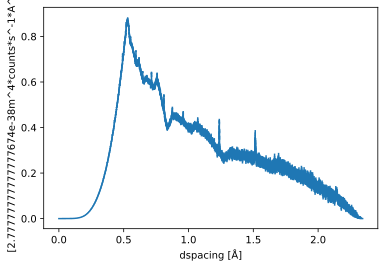

In [5]:
peaked_data.plot()

## Removing coherent scattering peaks

As the variable name `peaked_data` implies, the produced spectrum contains peaks from coherent scattering.
Even though the peaks are small for vanadium, we need to remove them to extract pure incoherent scattering.
We can approximate the coherent scattering contribution by fitting functions to the peaks and subtracting those fitted functions.
[scippneutron.peaks](https://scipp.github.io/scippneutron/generated/modules/scippneutron.peaks.html) contains general functionality for fitting and removing peaks.
Here, we use it through [ess.snspowder.powgen.peaks](../../generated/modules/ess.snspowder.powgen.peaks.rst), which provides useful defaults for vanadium peaks at POWGEN.
For example, it selects appropriate models for peaks (gaussian) and backgrounds (linear and quadratic).

First, define estimates for the peaks based on the known crystal structure of vanadium:

In [6]:
peak_estimates = powgen.peaks.theoretical_vanadium_dspacing(
    hkl_range=7, min_d=sc.scalar(0.41, unit='angstrom')
)

The fits require a bin-center coordinate, so convert from bin-edges:

In [7]:
to_fit = peaked_data.copy(deep=False)
to_fit.coords['dspacing'] = sc.midpoints(to_fit.coords['dspacing'])

Perform the fits:

In [8]:
fit_results = powgen.peaks.fit_vanadium_peaks(to_fit, peak_estimates=peak_estimates)

Remove the fitted peaks to obtain the incoherent scattering.
Also restore the bin-edge coordinate that we had to replace temporarily for the fits.

Importantly, we remove variances from the data.
If we kept the variances, subtracting the fitted models would introduce correlations between the data points.
This corresponds to [UncertaintyBroadcastMode.drop](../../generated/modules/ess.powder.types.UncertaintyBroadcastMode.rst) in the main workflow.
See also the [guide in ESSreduce](https://scipp.github.io/essreduce/user-guide/reduction-workflow-guidelines.html#s-8-propagation-of-uncertainties-in-broadcast-operations-should-support-drop-and-upper-bound-strategies-upper-bound-shall-be-the-default).

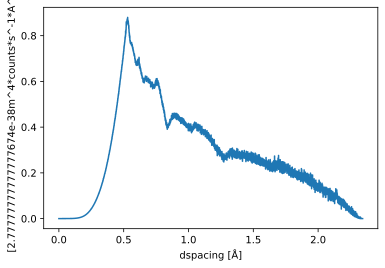

In [9]:
incoherent = scn.peaks.remove_peaks(sc.values(to_fit), fit_results)
incoherent.coords['dspacing'] = peaked_data.coords['dspacing']
incoherent.plot()

We can further inspect the results.
Below, there is a function that plots

- the data with coherent and incoherent scattering (blue),
- the resulting incoherent curve (green),
- the fitted models (orange),
- the fit windows (gray and red boxes),
- and the initial estimates (dashed vertical lines).

Some fits failed as indicated by red boxes and short descriptions of why the fits failed.
Some peaks are absent from the data used here, even though they are expected based on the crystal structure.
So those fits are expected to fail.
All other fits appear to have succeeded.

See [scippneutron.peaks.fit_peaks](https://scipp.github.io/scippneutron/generated/modules/scippneutron.peaks.fit_peaks.html) for options to customize the fit procedure if it does not work as desired.

<div class="alert alert-info">

**Note**

It is highly recommended to inspect the plot in detail to check whether all fits have succeeded or failed as expected!
Fitting is not always reliable and may fail for many reasons.
You can make plots interactive by using `%matplotlib widget`.

</div>

In [10]:
def peak_removal_diagnostic(
    data: sc.DataArray,
    removed: sc.DataArray,
    fit_results: list[scn.peaks.FitResult],
    peak_estimates: sc.Variable,
    *,
    xlim: tuple[sc.Variable, sc.Variable] | None = None,
):
    if xlim is not None:

        def in_range(x: sc.Variable) -> bool:
            return sc.isfinite(x) and (xlim[0] <= x) and (x < xlim[1])

        data = data[data.dim, xlim[0] : xlim[1]]
        removed = removed[removed.dim, xlim[0] : xlim[1]]
        fit_results, peak_estimates = zip(
            *(
                (r, e)
                for r, e in zip(fit_results, peak_estimates, strict=True)
                if in_range(r.window[0]) and in_range(r.window[1])
            ),
            strict=True,
        )

    # The actual data
    plot_data = {'data': data, 'removed': removed}
    linestyles = {}
    markers = {}
    colors = {'data': 'C0', 'removed': 'C2'}

    # Overlay with fit models evaluated at optimized parameters
    for i, result in enumerate(fit_results):
        if all(not sc.isnan(param).value for param in result.popt.values()):
            best_fit = data[data.dim, result.window[0] : result.window[1]].copy(
                deep=False
            )
            best_fit.coords[best_fit.dim] = sc.midpoints(best_fit.coords[best_fit.dim])
            best_fit.data = result.eval_model(best_fit.coords[best_fit.dim])

            key = f'result_{i}'
            plot_data[key] = best_fit
            linestyles[key] = '-'
            markers[key] = "none"
            colors[key] = "C1"

    fig = pp.plot(plot_data, ls=linestyles, marker=markers, c=colors, legend=False)
    ax = fig.ax

    # Initial estimates
    for estimate, result in zip(peak_estimates, fit_results, strict=True):
        ax.axvline(
            x=estimate.value,
            color="black" if result.success else "red",
            alpha=0.5,
            lw=1,
            ls=":",
        )

    # Fit windows
    for result in fit_results:
        left = result.window[0]
        right = result.window[1]
        sl = data[data.dim, left:right]
        lo = sl.min().value * 0.95
        hi = sl.max().value * 1.05
        ax.fill_betweenx(
            (lo, hi),
            left.value,
            right.value,
            facecolor="black" if result.success else "red",
            alpha=0.2,
        )
        if not result.success:
            ax.text(left.value, hi, result.message.split(":", 1)[0])

    return fig

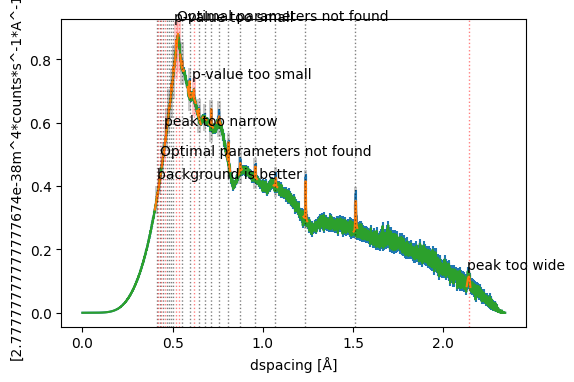

In [11]:
peak_removal_diagnostic(
    peaked_data,
    incoherent,
    fit_results,
    peak_estimates,
)

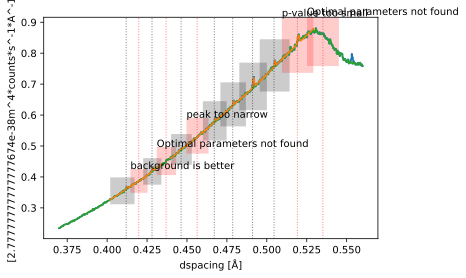

In [12]:
peak_removal_diagnostic(
    peaked_data,
    incoherent,
    fit_results,
    peak_estimates,
    xlim=(0.37 * sc.Unit("Å"), 0.56 * sc.Unit("Å")),
)

The resulting data array `incoherent` can be saved and used in the main workflow [POWGEN_data_reduction](../sns-instruments/POWGEN_data_reduction.rst) to replace `FocussedDataDspacing[VanadiumRun]`.